In [18]:
import cv2
import glob
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense

## Load and preprocessing data

In [2]:
def load_and_preprocess(src_dataset):
    path_images = glob.glob(src_dataset)

    X = []
    y = []
    
    for path in path_images:
        img = cv2.imread(path)
        img = cv2.resize(img, (32, 32))
        img = img / 255.0
        label = path.split("\\")[1]
        X.append(img)
        y.append(label)
        
    X = np.array(X)
    y = np.array(y)
    
    lb = LabelBinarizer()
    y = lb.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(X, y)

    return X_train, X_test, y_train, y_test

## Create CNN Model

In [ ]:
def model_cnn():
    model = Sequential([
        Conv2D(32, (3, 3), padding="same", activation="relu", input_shape=(32, 32, 3)),
        MaxPool2D(),
        Conv2D(64, (3, 3), padding="same", activation="relu"),
        MaxPool2D(),
        Flatten(),
        Dense(32, activation="relu"),
        Dense(10, activation="softmax")])

    model.compile(loss="categorical_crossentropy",
                 optimizer="rmsprop",
                 metrics = ["accuracy"])

    return model

In [4]:
path_images = "Data/*/*"
X_train, X_test, y_train, y_test = load_and_preprocess(path_images)

## Model information

In [17]:
model = model_cnn()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │         131,104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 150,826 (589.16 KB)

 Trainable params: 150,826 (589.16 KB)

 Non-trainable params: 0 (0.00 B)

## Fitting the model

In [21]:
model.fit(X_train, y_train, batch_size=32, epochs=25, validation_data=(X_test, y_test))

Epoch 1/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step - accuracy: 0.7908 - loss: 0.6522 - val_accuracy: 0.9535 - val_loss: 0.1514
Epoch 2/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9629 - loss: 0.1170 - val_accuracy: 0.9791 - val_loss: 0.0714
Epoch 3/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9803 - loss: 0.0619 - val_accuracy: 0.9799 - val_loss: 0.0589
Epoch 4/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.9883 - loss: 0.0346 - val_accuracy: 0.9744 - val_loss: 0.0861
Epoch 5/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9917 - loss: 0.0245 - val_accuracy: 0.9949 - val_loss: 0.0208
Epoch 6/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9944 - loss: 0.0164 - val_accuracy: 0.9866 - val_loss: 0.0368
Epoch 7/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.9963 - loss: 0.0112 - val_accuracy: 0.9961 - val_loss: 0.0149
Epoch 8/25
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9982 - loss: 0.0066 - val_ac

In [31]:
model.history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

## Accuracy and loss

Text(0.5, 1.0, 'accuracy')

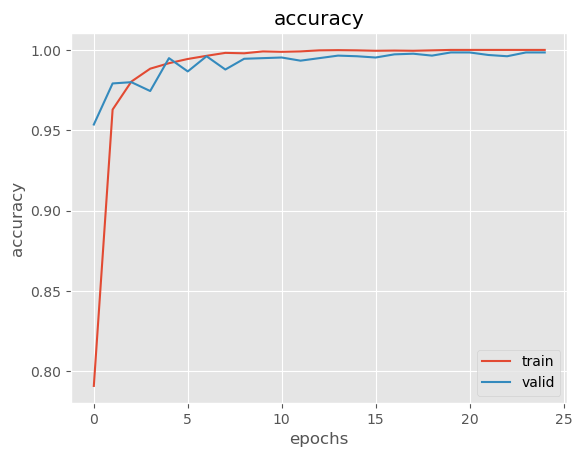

In [37]:
plt.plot(model.history.history["accuracy"])
plt.plot(model.history.history["val_accuracy"])
plt.legend(["train", "valid"])
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.title("accuracy")

Text(0.5, 1.0, 'loss')

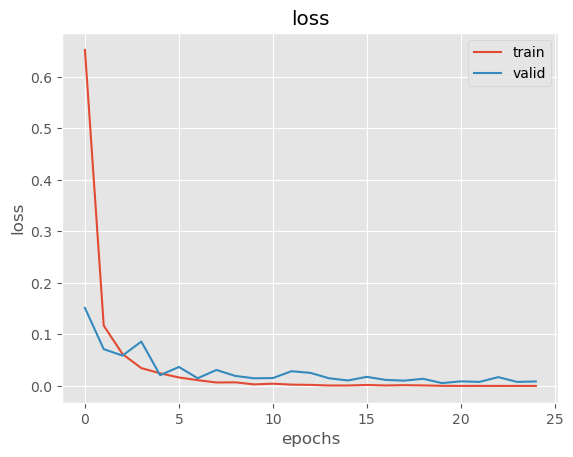

In [38]:
plt.plot(model.history.history["loss"])
plt.plot(model.history.history["val_loss"])
plt.legend(["train", "valid"])
plt.xlabel("epochs")
plt.ylabel("loss")
plt.title("loss")

In [40]:
model.save("digit_classifier_CNN.h5")